# **Multi-Class Classification of Malicious URLs**

# **Loading Files**

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('All.csv')

# Basic Info
df.info()

# First 5 rows
print("\n--- Head of Dataset ---")
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36707 entries, 0 to 36706
Data columns (total 80 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Querylength                      36707 non-null  int64  
 1   domain_token_count               36707 non-null  int64  
 2   path_token_count                 36707 non-null  int64  
 3   avgdomaintokenlen                36707 non-null  float64
 4   longdomaintokenlen               36707 non-null  int64  
 5   avgpathtokenlen                  36707 non-null  float64
 6   tld                              36707 non-null  int64  
 7   charcompvowels                   36707 non-null  int64  
 8   charcompace                      36707 non-null  int64  
 9   ldl_url                          36707 non-null  int64  
 10  ldl_domain                       36707 non-null  int64  
 11  ldl_path                         36707 non-null  int64  
 12  ldl_filename      

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.5,14,4.400000,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,0.0,-1.0,Defacement
1,0,4,5,5.5,14,6.000000,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.0,-1.0,Defacement
2,0,4,5,5.5,14,5.800000,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.0,-1.0,Defacement
3,0,4,12,5.5,14,5.500000,4,32,16,0,...,0,0,-1,0.640130,0.784493,0.814725,0.663210,0.0,-1.0,Defacement
4,0,4,6,5.5,14,7.333334,4,18,11,0,...,0,0,-1,0.681307,0.784493,0.814725,0.804526,0.0,-1.0,Defacement


# **Exploratory Data Analysis**

In [10]:
df.describe()

c:\Users\nithi\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_Directoryname,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath
count,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,...,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000
mean,21.908492,2.857439,8.954668,5.401719,9.746016,4.521506,2.857439,14.976517,10.216117,3.363909,...,1.727545,3.600049,2.685237,1.903261,0.722350,0.842443,0.521174,0.711232,0.507658,-0.208866
std,94.280609,0.906562,4.278406,1.986858,4.856580,2.856182,0.906562,13.351315,10.845807,13.447289,...,2.719231,4.783213,4.557171,4.512421,0.048820,0.066251,0.487556,0.414355,0.519682,0.891513
min,0.000000,2.000000,0.000000,1.500000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,0.419560,0.561913,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,2.000000,6.000000,4.000000,6.000000,3.000000,2.000000,7.000000,5.000000,0.000000,...,-1.000000,0.000000,0.000000,-1.000000,0.691929,0.795234,0.000000,0.718628,0.000000,-1.000000
50%,0.000000,3.000000,8.000000,5.000000,9.000000,4.000000,3.000000,13.000000,8.000000,0.000000,...,1.000000,1.000000,0.000000,-1.000000,0.723003,0.835752,0.750717,0.784744,0.728721,-1.000000
75%,19.000000,3.000000,11.000000,6.500000,12.000000,5.000000,3.000000,19.000000,12.000000,1.000000,...,3.000000,6.000000,4.000000,3.000000,0.754305,0.884735,0.827729,0.884311,0.907449,0.758695
max,1385.000000,19.000000,68.000000,29.500000,63.000000,105.000000,19.000000,193.000000,142.000000,207.000000,...,24.000000,40.000000,39.000000,40.000000,0.895403,1.000000,0.962479,1.000000,1.000000,1.000000


## **Missing Values Analysis**
This block checks for any null or missing entries in the dataset.

In [11]:
# Check for missing values
missing_values = df.isnull().sum()
print("\n--- Missing Values Count ---")
print(missing_values[missing_values > 0])

# Summary of missing values
if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print(f"Total missing values: {missing_values.sum()}")


--- Missing Values Count ---
Series([], dtype: int64)
No missing values found in the dataset.


## **Target Variable Distribution**
Visualizing the balance between classes (Benign vs. various Malicious types).

C:\Users\nithi\AppData\Local\Temp\ipykernel_15824\3128245009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='URL_Type_obf_Type', palette='viridis', order=df['URL_Type_obf_Type'].value_counts().index)


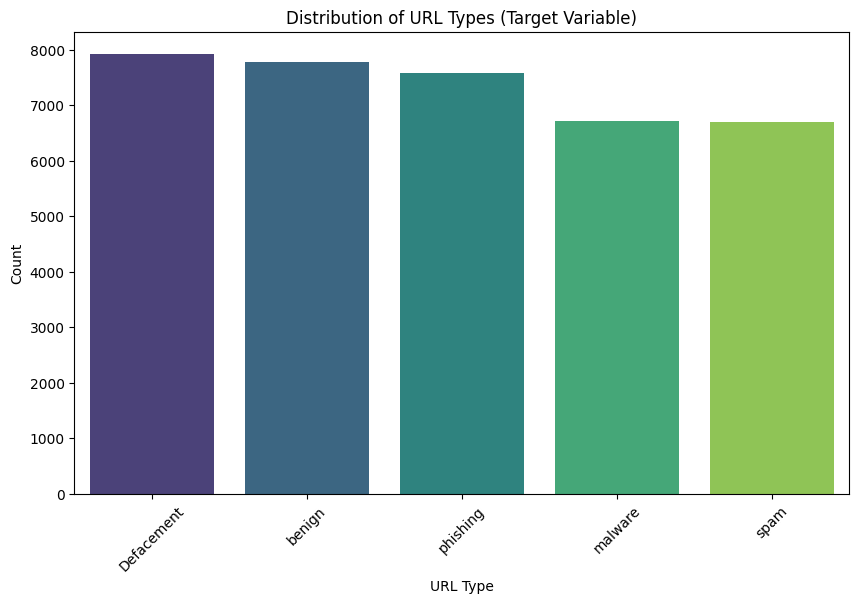

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='URL_Type_obf_Type', palette='viridis', order=df['URL_Type_obf_Type'].value_counts().index)
plt.title('Distribution of URL Types (Target Variable)')
plt.xlabel('URL Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## **Correlation Heatmap**
Since there are 80 columns, we visualize the correlation between the first 15 features to keep the heatmap readable.

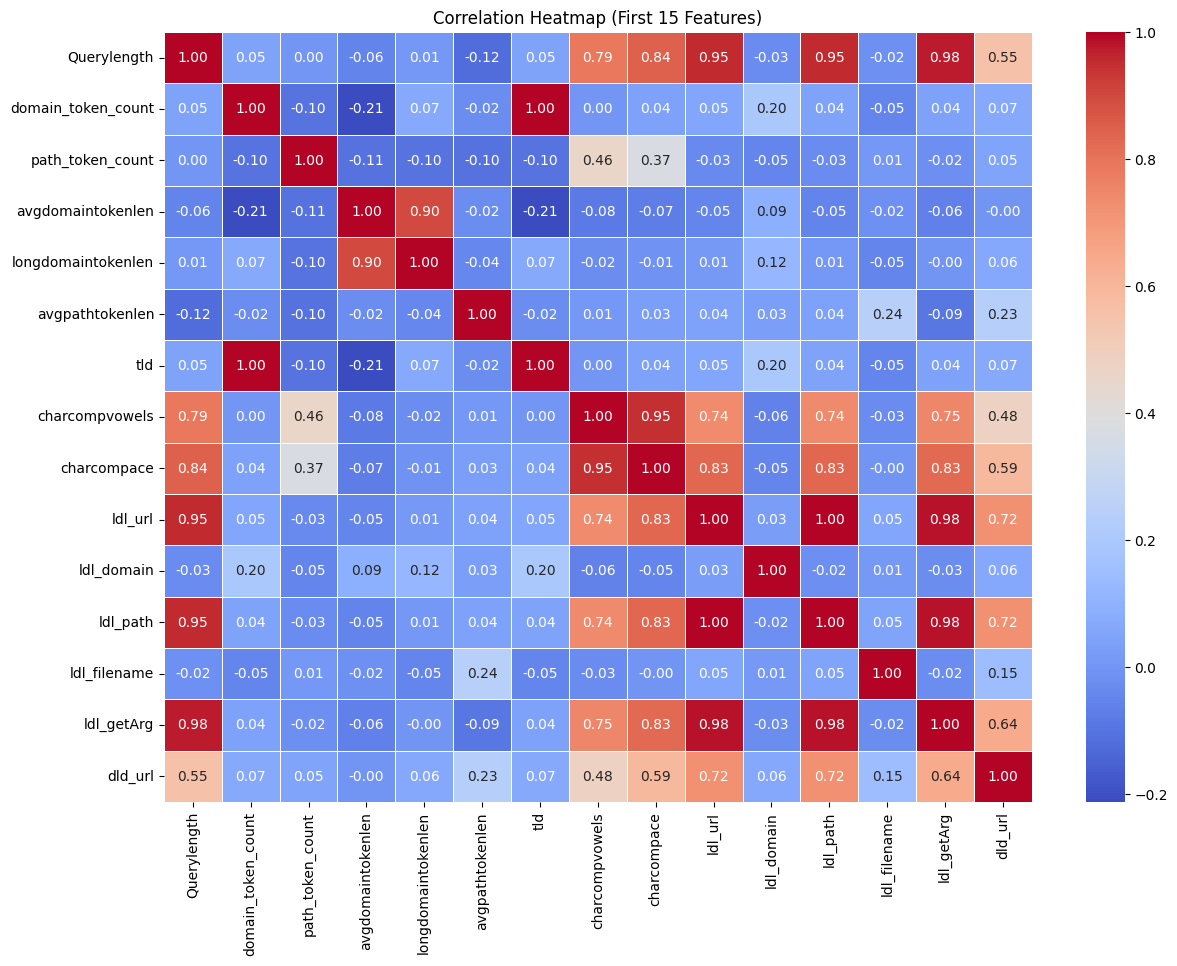

In [13]:
plt.figure(figsize=(14, 10))
# Selecting a subset of features for better visibility
subset_corr = df.iloc[:, :15].join(df['URL_Type_obf_Type'])
corr_matrix = subset_corr.select_dtypes(include=['number']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (First 15 Features)')
plt.show()

## **Distribution Graphs**
Histograms for key features like URL length and Entropy to understand their spread.

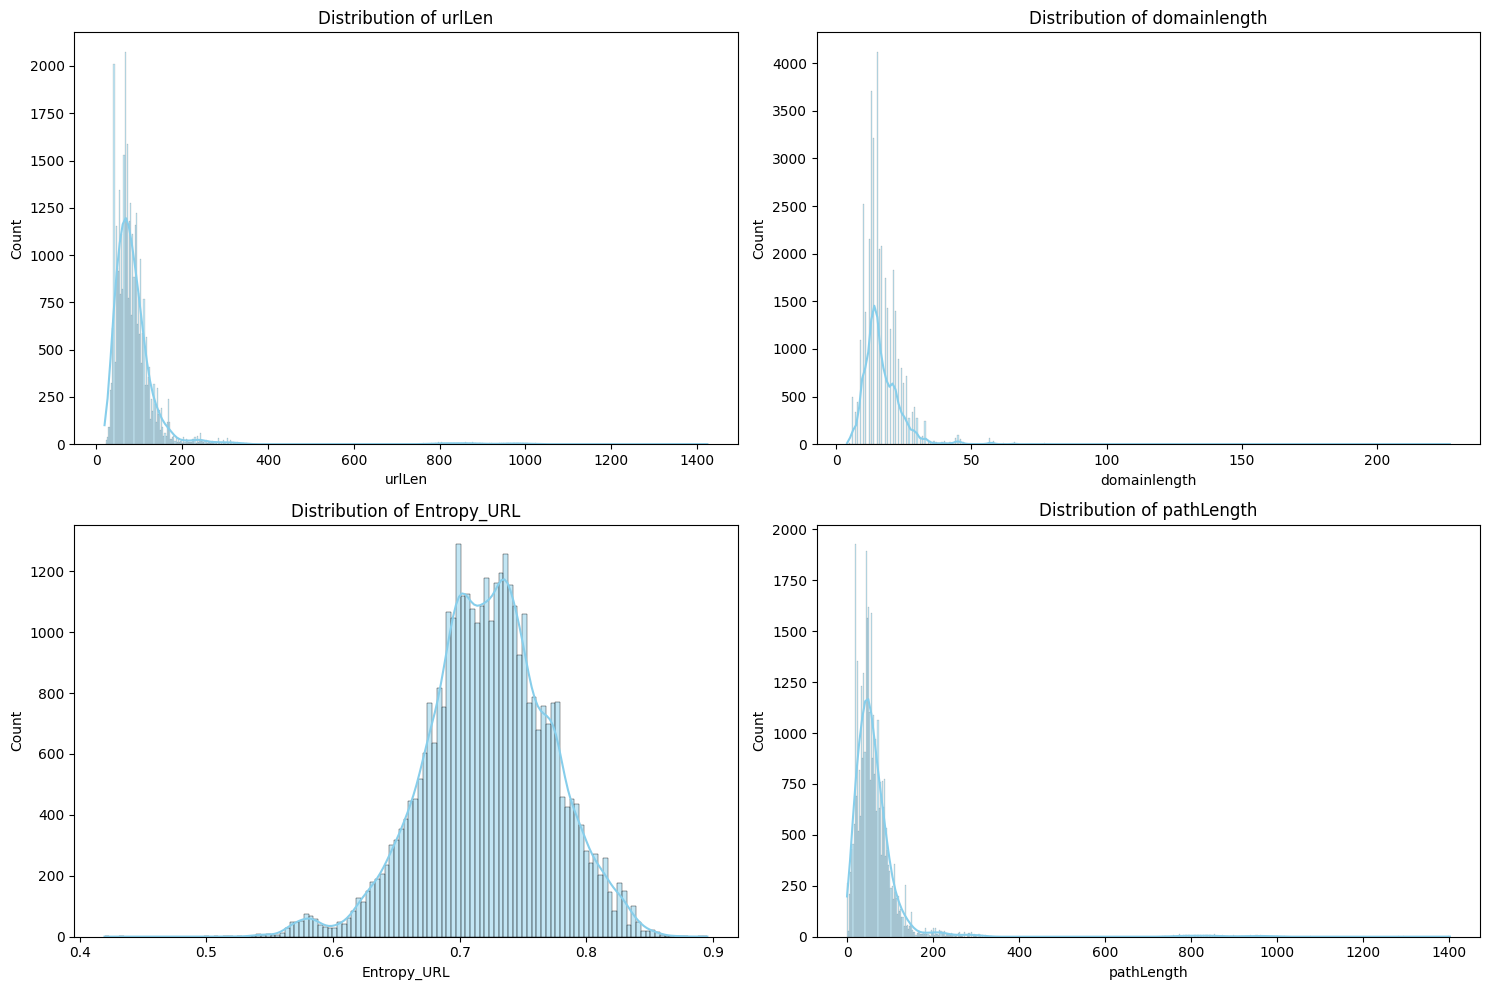

In [14]:
features_to_plot = ['urlLen', 'domainlength', 'Entropy_URL', 'pathLength']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

## **Pair Plot**
Visualizing relationships between a selected subset of features colored by the target class.

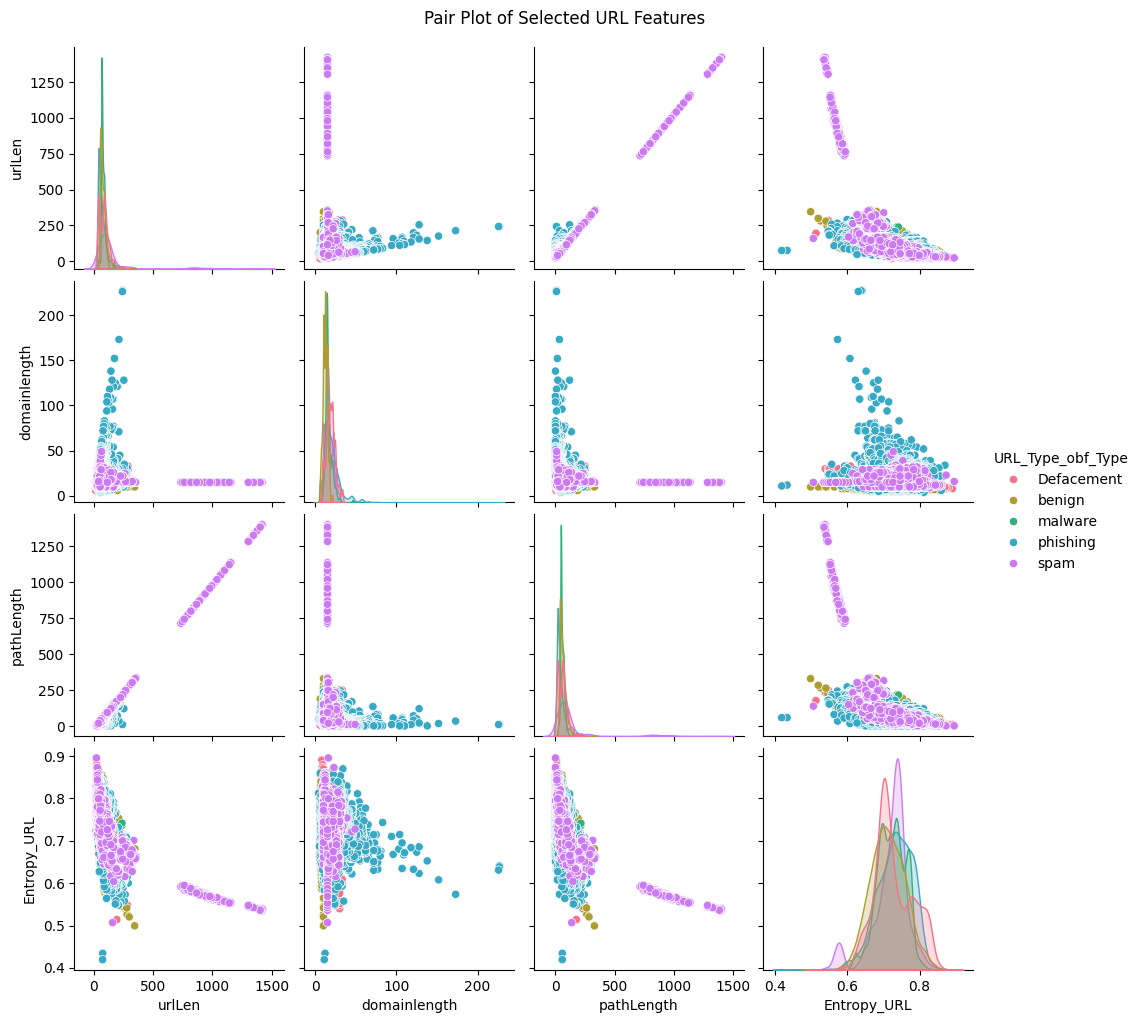

In [15]:
# Selecting a few representative features for the pair plot
pairplot_features = ['urlLen', 'domainlength', 'pathLength', 'Entropy_URL', 'URL_Type_obf_Type']
sns.pairplot(df[pairplot_features], hue='URL_Type_obf_Type', palette='husl', diag_kind='kde')
plt.suptitle('Pair Plot of Selected URL Features', y=1.02)
plt.show()

df.head()

In [16]:
df.head()

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.5,14,4.400000,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,0.0,-1.0,Defacement
1,0,4,5,5.5,14,6.000000,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.0,-1.0,Defacement
2,0,4,5,5.5,14,5.800000,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.0,-1.0,Defacement
3,0,4,12,5.5,14,5.500000,4,32,16,0,...,0,0,-1,0.640130,0.784493,0.814725,0.663210,0.0,-1.0,Defacement
4,0,4,6,5.5,14,7.333334,4,18,11,0,...,0,0,-1,0.681307,0.784493,0.814725,0.804526,0.0,-1.0,Defacement


# **Data Preprocessing**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc, classification_report)
from itertools import cycle

# 1. Define Features and Target
# Assuming 'df' is your loaded dataframe
X = df.drop('URL_Type_obf_Type', axis=1)
y = df['URL_Type_obf_Type']

# 2. Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_
n_classes = len(classes)

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# **Model Training & Evaluation**

In [18]:
import time
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import numpy as np # Import numpy for nan

# Handle infinite values before training
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Initialize models
models = {
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, objective='multi:softprob', random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Dictionary to store results
results = {}

# Training loop
for name, model in models.items():
    print(f"Training {name}...")

    # Calculate Training Time
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Calculate Testing (Inference) Time
    start_test = time.time()
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)
    test_time = time.time() - start_test

    # Store predictions, probability scores, and timings
    results[name] = {
        'y_pred': y_pred,
        'y_score': y_score,
        'train_time': train_time,
        'test_time': test_time
    }

    print(f"{name} - Train Time: {train_time:.4f}s, Test Time: {test_time:.4f}s")

Training XGBoost...
XGBoost - Train Time: 7.0462s, Test Time: 0.1886s
Training RandomForest...
RandomForest - Train Time: 2.7010s, Test Time: 0.3585s
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010279 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9558
[LightGBM] [Info] Number of data points in the train set: 29365, number of used features: 77
[LightGBM] [Info] Start training from score -1.532294
[LightGBM] [Info] Start training from score -1.551230
[LightGBM] [Info] Start training from score -1.699162
[LightGBM] [Info] Start training from score -1.576610
[LightGBM] [Info] Start training from score -1.701213
LightGBM - Train Time: 7.4503s, Test Time: 0.2830s


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metrics_list = []

for name, res in results.items():
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, res['y_pred']),
        'Precision': precision_score(y_test, res['y_pred'], average='weighted'),
        'Recall': recall_score(y_test, res['y_pred'], average='weighted'),
        'F1-Score': f1_score(y_test, res['y_pred'], average='weighted'),
        'Train Time (s)': res['train_time'],
        'Test Time (s)': res['test_time']
    }
    metrics_list.append(metrics)

# Display as a nice table
comparison_df = pd.DataFrame(metrics_list)

# Optional: Rounding for better readability in the console
print(comparison_df.round(4))

          Model  Accuracy  Precision  Recall  F1-Score  Train Time (s)  \
0       XGBoost    0.9744     0.9744  0.9744    0.9744          7.0462   
1  RandomForest    0.9771     0.9774  0.9771    0.9772          2.7010   
2      LightGBM    0.9856     0.9856  0.9856    0.9856          7.4503   

   Test Time (s)  
0         0.1886  
1         0.3585  
2         0.2830  


## **Confusion Matrix**

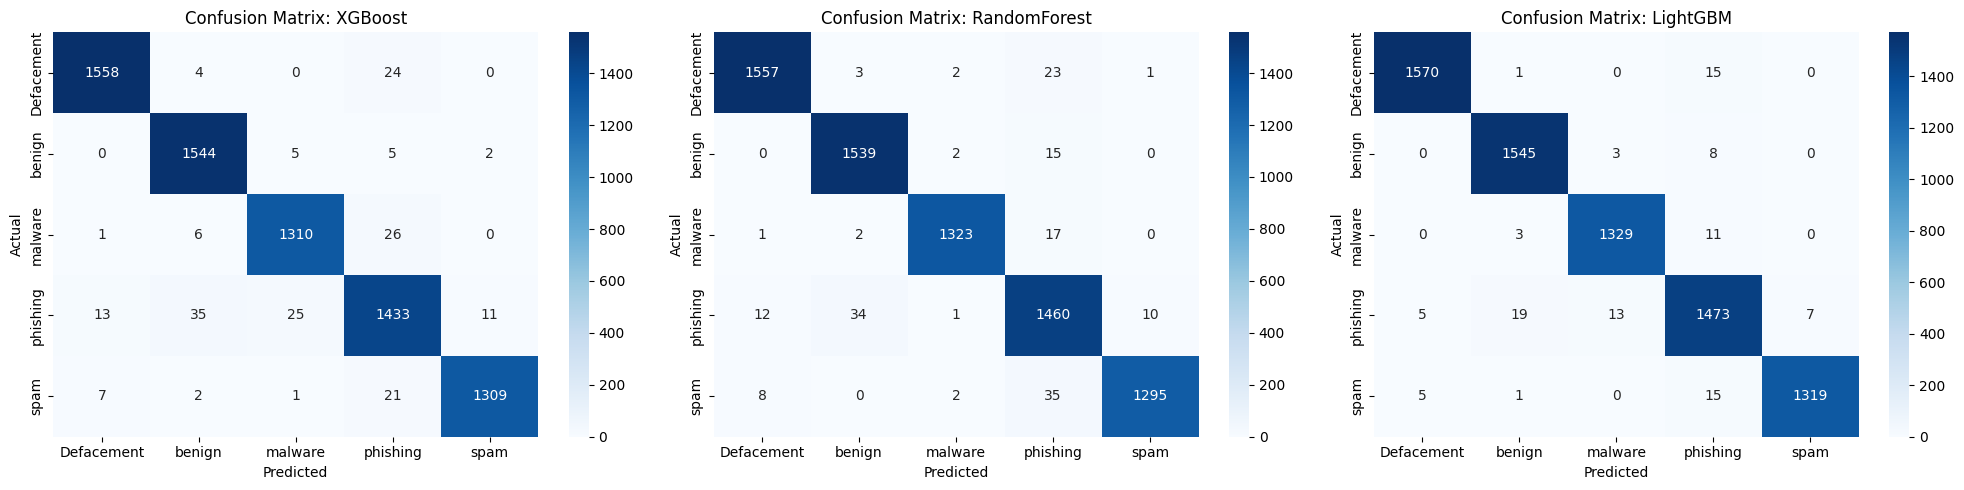

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## **ROC Curve**

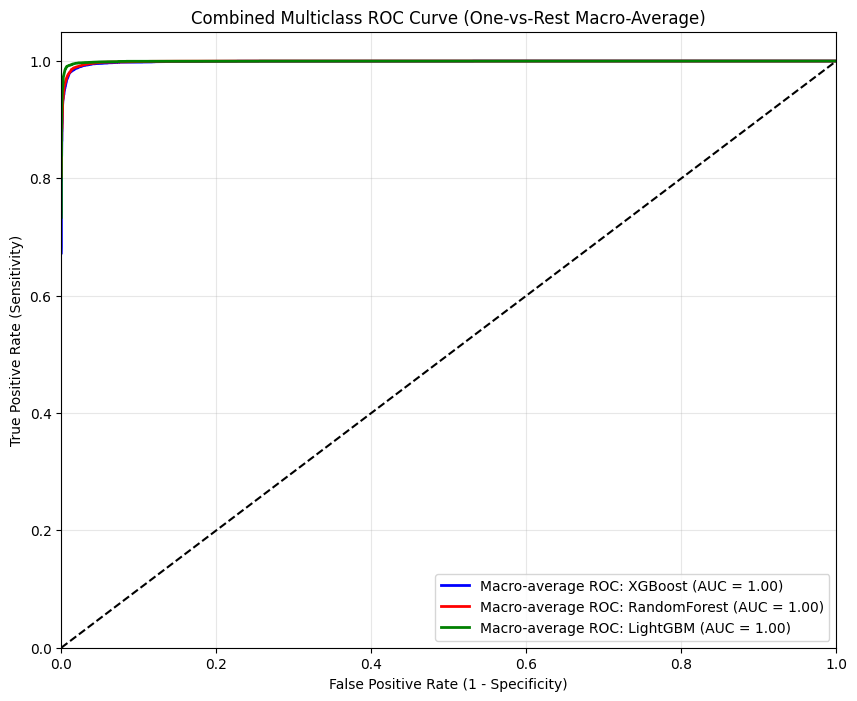

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle

# 1. Binarize the output for multiclass plotting
# 'classes' should be the unique list of your target labels
classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])

for (name, res), color in zip(results.items(), colors):
    y_score = res['y_score']

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    # Compute Macro-average ROC curve
    # First aggregate all false positive rates
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    # Then interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    # Finally average it and compute AUC
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    # Plot the macro-average curve for this model
    plt.plot(all_fpr, mean_tpr, color=color, lw=2,
             label=f'Macro-average ROC: {name} (AUC = {macro_auc:.2f})')

# Layout settings
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Combined Multiclass ROC Curve (One-vs-Rest Macro-Average)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## **Hyperparameter Tuning using Grid Search**

Optimizing XGBoost...
Optimizing RandomForest...
Optimizing LightGBM...

--- Model Comparison Table ---
          Model  Accuracy  Precision    Recall  F1-Score  Train Time (s)  \
0       XGBoost  0.974394   0.974437  0.974394  0.974379         35.6821   
1  RandomForest  0.977118   0.977390  0.977118  0.977186         16.2884   
2      LightGBM  0.985563   0.985600  0.985563  0.985571         39.4031   

   Test Time (s)  
0         0.0646  
1         0.1939  
2         0.2060  


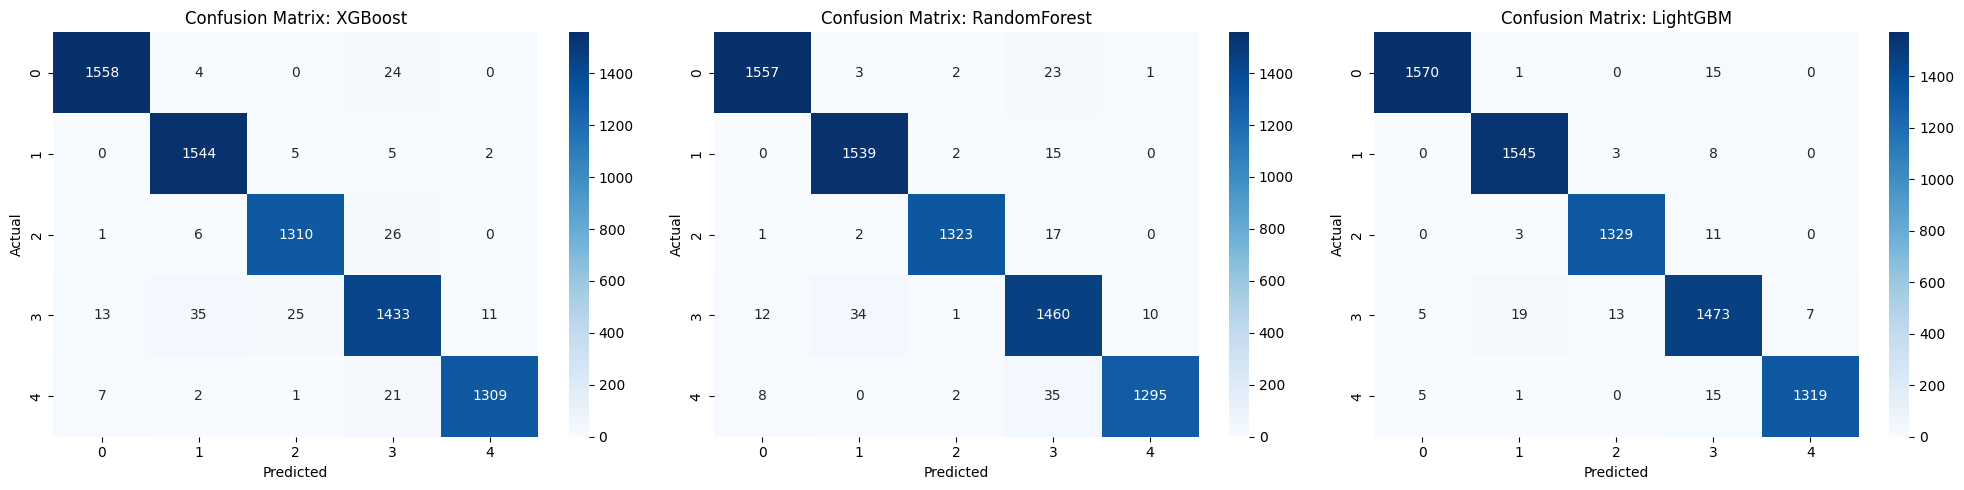

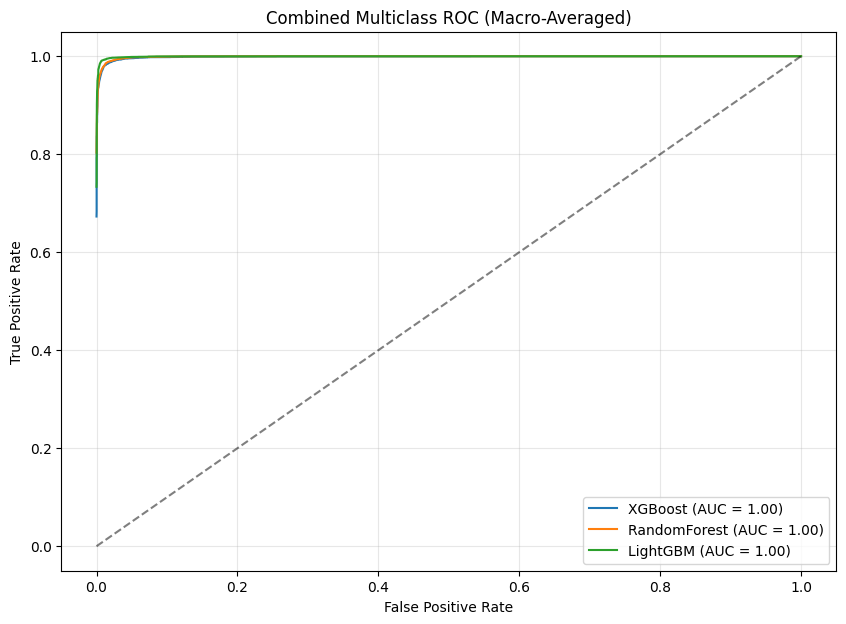

In [22]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# 1. Preprocessing (Handling Inf values)
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Define Parameter Grids for Grid Search
param_grids = {
    "XGBoost": {
        'n_estimators': [50, 100],
        'max_depth': [3, 6],
        'learning_rate': [0.1],
        'objective': ['multi:softprob']
    },
    "RandomForest": {
        'n_estimators': [50, 100],
        'max_depth': [None, 10],
        'n_jobs': [-1]
    },
    "LightGBM": {
        'n_estimators': [50, 100],
        'learning_rate': [0.1],
        'objective': ['multiclass'],
        'verbosity': [-1]
    }
}

# Base models for GridSearch
base_models = {
    "XGBoost": XGBClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

results = {}
metrics_list = []

# 3. Optimization and Evaluation Loop
for name, model in base_models.items():
    print(f"Optimizing {name}...")

    # Grid Search
    grid_search = GridSearchCV(model, param_grids[name], cv=3, scoring='f1_weighted', n_jobs=-1)

    start_train = time.time()
    grid_search.fit(X_train, y_train)
    train_time = time.time() - start_train

    best_model = grid_search.best_estimator_

    # Prediction and Timing
    start_test = time.time()
    y_pred = best_model.predict(X_test)
    test_time = time.time() - start_test

    y_score = best_model.predict_proba(X_test)

    # Store data for plots
    results[name] = {'y_pred': y_pred, 'y_score': y_score, 'model': best_model}

    # Calculate Metrics
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted'),
        'Train Time (s)': round(train_time, 4),
        'Test Time (s)': round(test_time, 4)
    })

# Display Metrics Table
comparison_df = pd.DataFrame(metrics_list)
print("\n--- Model Comparison Table ---")
print(comparison_df)

# 4. Visualizations: Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# 5. Visualizations: Multiclass Combined ROC Curve (Macro-Average)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

plt.figure(figsize=(10, 7))
for name, res in results.items():
    y_score = res['y_score']
    fpr, tpr = dict(), dict()

    for j in range(n_classes):
        fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], y_score[:, j])

    # Macro-average calculation
    all_fpr = np.unique(np.concatenate([fpr[j] for j in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for j in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[j], tpr[j])
    mean_tpr /= n_classes

    plt.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {auc(all_fpr, mean_tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Combined Multiclass ROC (Macro-Averaged)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## **K-Fold Cross Validation**

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_validate
import pandas as pd
import time

# Storage for results
all_metrics = []
model_predictions = {}

# Define metrics to track during Cross-Validation
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

for name, model in models.items():
    print(f"Evaluating {name} with Cross-Validation...")

    # 1. Perform Cross-Validation to get Mean and Standard Deviation
    cv_results = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)

    # 2. Final Training and Timing (on full training set)
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # 3. Final Prediction and Timing (on test set)
    start_test = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    test_time = time.time() - start_test

    # Save for later blocks (ROC/Confusion Matrix)
    model_predictions[name] = {'pred': y_pred, 'prob': y_prob}

    # 4. Compile Metrics with Standard Deviation
    metrics = {
        'Model': name,
        'Accuracy (Mean)': cv_results['test_accuracy'].mean(),
        'Accuracy (Std)': cv_results['test_accuracy'].std(),
        'F1-Score (Mean)': cv_results['test_f1_weighted'].mean(),
        'F1-Score (Std)': cv_results['test_f1_weighted'].std(),
        'Precision (Mean)': cv_results['test_precision_weighted'].mean(),
        'Recall (Mean)': cv_results['test_recall_weighted'].mean(),
        'Train Time (s)': train_time,
        'Test Time (s)': test_time
    }
    all_metrics.append(metrics)

# Display Comparison Table
results_df = pd.DataFrame(all_metrics)
print("\n--- Model Performance Comparison (with 5-Fold CV Standard Deviation) ---")
print(results_df.round(4).to_string(index=False))

Evaluating XGBoost with Cross-Validation...
Evaluating RandomForest with Cross-Validation...
Evaluating LightGBM with Cross-Validation...

--- Model Performance Comparison (with 5-Fold CV Standard Deviation) ---
       Model  Accuracy (Mean)  Accuracy (Std)  F1-Score (Mean)  F1-Score (Std)  Precision (Mean)  Recall (Mean)  Train Time (s)  Test Time (s)
     XGBoost           0.9720          0.0014           0.9720          0.0014            0.9721         0.9720          7.3439         0.1851
RandomForest           0.9735          0.0013           0.9736          0.0013            0.9738         0.9735          2.7079         0.3679
    LightGBM           0.9818          0.0012           0.9818          0.0012            0.9818         0.9818         63.0823         2.7652


# **Robust Discriminator Analysis**

Top Discriminative Lexical Features (Defacement vs. Phishing):
              Lexical_Feature  Importance
27                ArgUrlRatio    0.310440
69  SymbolCount_Directoryname    0.129560
43           Query_DigitCount    0.105919
56        URLQueries_variable    0.041675
9                     ldl_url    0.038882
71      SymbolCount_Extension    0.027297
65       NumberRate_Extension    0.024545
24            this.fileExtLen    0.017291
61             NumberRate_URL    0.016978
64        NumberRate_FileName    0.016561


C:\Users\nithi\AppData\Local\Temp\ipykernel_15824\2350257674.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Lexical_Feature', data=feat_df, palette='magma')


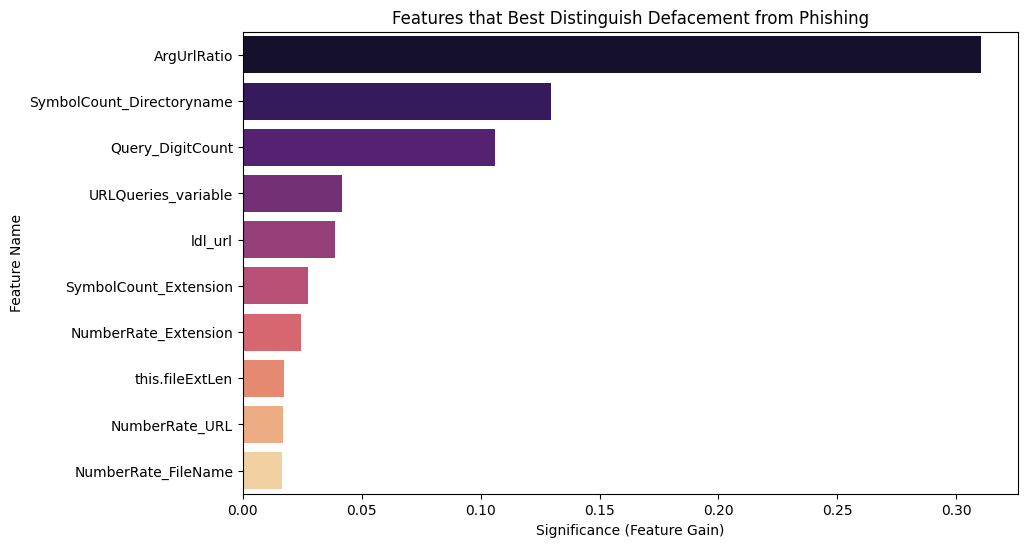


Mean values for 'ArgUrlRatio':
URL_Type_obf_Type
Defacement    0.404255
phishing      0.089009
Name: ArgUrlRatio, dtype: float64


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# 1. Filter for the two specific classes
target_classes = ['Defacement', 'phishing'] # Corrected 'Phishing' to 'phishing'
mask = df['URL_Type_obf_Type'].isin(target_classes)
df_subset = df[mask].copy()

# 2. Data Cleaning: Crucial to fix the 'base_score' / Logistic Loss error
# Replace Infinity with NaN and fill all missing values with 0
X_bin = df_subset.drop('URL_Type_obf_Type', axis=1).replace([np.inf, -np.inf], np.nan).fillna(0)
y_bin_labels = df_subset['URL_Type_obf_Type']

# 3. Encode labels (Defacement will be 0, Phishing will be 1)
le_bin = LabelEncoder()
y_bin = le_bin.fit_transform(y_bin_labels)

# 4. Train a binary XGBoost model to find discriminators
# objective='binary:logistic' ensures it focuses strictly on the difference between these two
compare_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    objective='binary:logistic',
    importance_type='gain' # 'gain' shows the actual contribution to accuracy
)
compare_model.fit(X_bin, y_bin)

# 5. Extract and Visualize the top discriminators
importances = compare_model.feature_importances_
feat_df = pd.DataFrame({'Lexical_Feature': X_bin.columns, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

print("Top Discriminative Lexical Features (Defacement vs. Phishing):")
print(feat_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Lexical_Feature', data=feat_df, palette='magma')
plt.title('Features that Best Distinguish Defacement from Phishing')
plt.xlabel('Significance (Feature Gain)')
plt.ylabel('Feature Name')
plt.show()

# 6. Statistical verification of the top feature
top_feature = feat_df.iloc[0]['Lexical_Feature']
means = df_subset.groupby('URL_Type_obf_Type')[top_feature].mean()
print(f"\nMean values for '{top_feature}':")
print(means)

# **Comparision of Binary and Multi Class Accuracy**

Training XGBoost Binary Model...
Training RandomForest Binary Model...
Training LightGBM Binary Model...

--- Binary Model Comparison Table ---
          Model  Accuracy  Precision    Recall  F1-Score  Train Time (s)  \
0       XGBoost  0.991147   0.995325  0.993432  0.994378         14.9648   
1  RandomForest  0.993598   0.995853  0.996025  0.995939         18.5703   
2      LightGBM  0.993462   0.995681  0.996025  0.995853         71.8058   

   Test Time (s)  
0         0.3868  
1         0.7515  
2         0.8672  


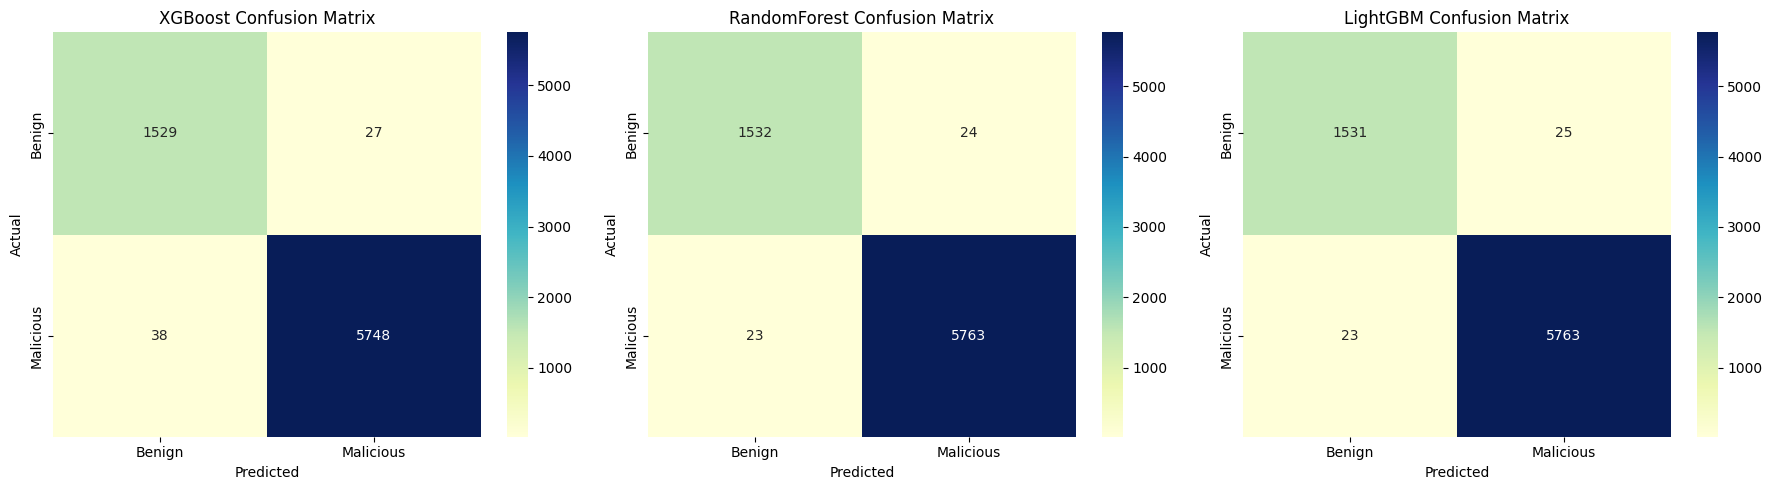

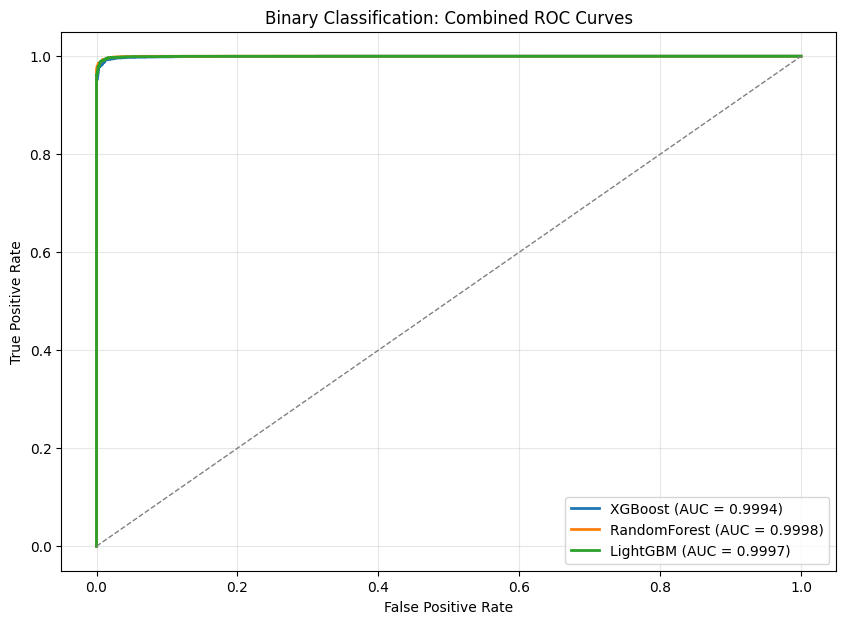

In [25]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc, classification_report)

# 1. Setup Binary Labels and Data Cleaning
# Benign = 0, Malicious = 1
y_binary = df['URL_Type_obf_Type'].apply(lambda x: 0 if x == 'benign' else 1).values
X_clean = df.drop('URL_Type_obf_Type', axis=1).replace([np.inf, -np.inf], np.nan).fillna(0)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_clean, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 2. Initialize Models directly
models = {
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        objective='binary:logistic',
        base_score=0.5,
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        objective='binary',
        random_state=42,
        verbosity=-1
    )
}

results = {}
metrics_list = []

# 3. Training and Evaluation Loop
for name, model in models.items():
    print(f"Training {name} Binary Model...")

    # Training Time
    start_train = time.time()
    model.fit(X_train_bin, y_train_bin)
    train_time = time.time() - start_train

    # Prediction Time
    start_test = time.time()
    y_pred = model.predict(X_test_bin)
    test_time = time.time() - start_test

    # Probability for ROC (Positive Class)
    y_score = model.predict_proba(X_test_bin)[:, 1]

    results[name] = {'y_pred': y_pred, 'y_score': y_score}

    # Metrics Calculation
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_bin, y_pred),
        'Precision': precision_score(y_test_bin, y_pred),
        'Recall': recall_score(y_test_bin, y_pred),
        'F1-Score': f1_score(y_test_bin, y_pred),
        'Train Time (s)': round(train_time, 4),
        'Test Time (s)': round(test_time, 4)
    })

# 4. Comparison Table
comparison_df = pd.DataFrame(metrics_list)
print("\n--- Binary Model Comparison Table ---")
print(comparison_df)

# 5. Confusion Matrix Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test_bin, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[i],
                xticklabels=['Benign', 'Malicious'], yticklabels=['Benign', 'Malicious'])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# 6. Combined ROC Curve Visualization

plt.figure(figsize=(10, 7))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test_bin, res['y_score'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Binary Classification: Combined ROC Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [26]:
import joblib

# 1. Save the best model (LightGBM)
joblib.dump(models['LightGBM'], 'best_lgbm_model.pkl')

# 2. Save the column names to ensure the order is correct during prediction
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

# 3. Save the label encoder to convert numbers back to text (e.g., 0 -> 'Malware')
joblib.dump(le, 'label_encoder.pkl')

print("Model and metadata saved successfully!")

Model and metadata saved successfully!


In [ ]:
import joblib
import numpy as np
from sklearn.metrics import accuracy_score

# Retrain fresh multiclass LightGBM — no dependency on models variable
from lightgbm import LGBMClassifier

lgbm_final = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    objective='multiclass',
    num_class=5,
    random_state=42,
    verbosity=-1
)

X_tr = X_train.copy().replace([np.inf, -np.inf], np.nan).fillna(0)
X_te = X_test.copy().replace([np.inf, -np.inf], np.nan).fillna(0)

lgbm_final.fit(X_tr, y_train)

acc = accuracy_score(y_test, lgbm_final.predict(X_te))
print(f"Accuracy: {acc*100:.2f}%")

In [ ]:
# Save with correct names matching app.py
joblib.dump(lgbm_final,          'best_lgbm_model.pkl')
joblib.dump(le,                   'label_encoder.pkl')
joblib.dump(list(X_tr.columns),  'feature_columns.pkl')

print("Saved successfully")
print("Classes:", list(le.classes_))

# **Real Time Prediction**

In [27]:
pip install tldextract

Note: you may need to restart the kernel to use updated packages.


In [28]:
import re
import math
import tldextract
import joblib
import numpy as np
import pandas as pd
from urllib.parse import urlparse
from collections import Counter
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. YOUR EXTRACTION FUNCTIONS ---
def get_entropy(text):
    if not text: return 0.0
    p, lns = Counter(text), float(len(text))
    return -sum(count/lns * math.log2(count/lns) for count in p.values())

def extract_url_features(url):
    parsed = urlparse(url)
    ext = tldextract.extract(url)
    domain = ext.domain + '.' + ext.suffix
    path = parsed.path
    query = parsed.query
    filename = path.split('/')[-1] if '/' in path else ''
    directory = path.rsplit('/', 1)[0] if '/' in path else ''
    extension = filename.split('.')[-1] if '.' in filename else ''
    after_path = url.split(path)[-1] if path else ''
    domain_tokens = re.split(r'\.|\-', ext.domain)
    path_tokens = [t for t in re.split(r'\/|\-|\_|\.', path) if t]

    features = {}
    features['Querylength'] = len(query)
    features['domain_token_count'] = len(domain_tokens)
    features['path_token_count'] = len(path_tokens)
    features['avgdomaintokenlen'] = sum(len(t) for t in domain_tokens) / len(domain_tokens) if domain_tokens else 0
    features['longdomaintokenlen'] = max([len(t) for t in domain_tokens]) if domain_tokens else 0
    features['avgpathtokenlen'] = sum(len(t) for t in path_tokens) / len(path_tokens) if path_tokens else 0
    features['tld'] = len(ext.suffix)
    features['charcompvowels'] = sum(1 for char in url if char.lower() in 'aeiou')
    features['charcompace'] = sum(1 for char in url if char.lower() in 'ace')
    ldl_pattern = r'[a-zA-Z][0-9][a-zA-Z]'
    features['ldl_url'] = len(re.findall(ldl_pattern, url))
    features['ldl_domain'] = len(re.findall(ldl_pattern, domain))
    features['ldl_path'] = len(re.findall(ldl_pattern, path))
    features['ldl_filename'] = len(re.findall(ldl_pattern, filename))
    features['ldl_getArg'] = len(re.findall(ldl_pattern, query))
    features['urlLen'] = len(url)
    features['domainlength'] = len(domain)
    features['pathLength'] = len(path)
    features['subDirLen'] = len(directory)
    features['fileNameLen'] = len(filename)
    features['this.fileExtLen'] = len(extension)
    features['ArgLen'] = len(query)
    features['pathurlRatio'] = len(path) / len(url) if len(url) > 0 else 0
    features['ArgUrlRatio'] = len(query) / len(url) if len(url) > 0 else 0
    features['argDomanRatio'] = len(query) / len(domain) if len(domain) > 0 else 0
    features['domainUrlRatio'] = len(domain) / len(url) if len(url) > 0 else 0
    features['pathDomainRatio'] = len(path) / len(domain) if len(domain) > 0 else 0
    features['argPathRatio'] = len(query) / len(path) if len(path) > 0 else 0
    features['executable'] = 1 if any(url.endswith(e) for e in ['.exe', '.dll', '.sh']) else 0
    features['isPortEighty'] = 1 if parsed.port == 80 else 0
    features['NumberofDotsinURL'] = url.count('.')
    features['ISIpAddressInDomainName'] = 1 if re.match(r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$', ext.domain) else 0
    features['URL_DigitCount'] = sum(c.isdigit() for c in url)
    features['host_DigitCount'] = sum(c.isdigit() for c in domain)
    features['Directory_DigitCount'] = sum(c.isdigit() for c in directory)
    features['File_name_DigitCount'] = sum(c.isdigit() for c in filename)
    features['Extension_DigitCount'] = sum(c.isdigit() for c in extension)
    features['Query_DigitCount'] = sum(c.isdigit() for c in query)
    features['NumberRate_URL'] = features['URL_DigitCount'] / len(url) if len(url) > 0 else 0
    features['NumberRate_Domain'] = features['host_DigitCount'] / len(domain) if len(domain) > 0 else 0
    features['Entropy_URL'] = get_entropy(url)
    features['Entropy_Domain'] = get_entropy(domain)
    features['Entropy_DirectoryName'] = get_entropy(directory)
    features['Entropy_Filename'] = get_entropy(filename)
    features['Entropy_Extension'] = get_entropy(extension)
    features['Entropy_Afterpath'] = get_entropy(after_path)
    return features

# --- 2. PREDICTION LOGIC ---
model = joblib.load("D:/All Documents/Projects/Sony_Padhu/Sony Final/best_lgbm_model.pkl")
encoder = joblib.load("D:/All Documents/Projects/Sony_Padhu/Sony Final/label_encoder.pkl")
expected_columns = joblib.load("D:/All Documents/Projects/Sony_Padhu/Sony Final/feature_columns.pkl")

def predict_single_url(url):
    features_dict = extract_url_features(url)
    df_row = pd.DataFrame([features_dict])
    # Align features with the training set
    df_row = df_row.reindex(columns=expected_columns, fill_value=0)

    prediction_numeric = model.predict(df_row)[0]
    prediction_label = encoder.inverse_transform([prediction_numeric])[0]
    probabilities = model.predict_proba(df_row)[0]
    return prediction_label, np.max(probabilities)

# --- 3. INTERACTIVE UI ---
input_box = widgets.Text(placeholder='Enter URL...', description='URL:', layout={'width': '80%'})
button = widgets.Button(description='Analyze URL', button_style='success')
output = widgets.Output()

def on_click_analyze(b):
    with output:
        clear_output()
        url = input_box.value
        if url:
            label, conf = predict_single_url(url)
            color = "green" if label.lower() == "benign" else "red"
            display(widgets.HTML(f"""
                <div style="border: 2px solid {color}; padding: 15px; border-radius: 8px;">
                    <h3 style="color: {color}; margin: 0;">Result: {label.upper()}</h3>
                    <p style="margin: 5px 0;"><b>Confidence:</b> {conf*100:.2f}%</p>
                    <small>URL: {url}</small>
                </div>
            """))
        else:
            print("Please enter a URL.")

button.on_click(on_click_analyze)
display(widgets.HTML("<h2>URL Security Checker</h2>"), input_box, button, output)

HTML(value='<h2>URL Security Checker</h2>')

Text(value='', description='URL:', layout=Layout(width='80%'), placeholder='Enter URL...')

Button(button_style='success', description='Analyze URL', style=ButtonStyle())

Output()

In [35]:
import joblib
m = joblib.load('best_lgbm_model.pkl')
print(m.objective_)
print(m.n_classes_)

multiclass
5
